# Sequence Jackknife and Neutral-Context Bootstrap under the M/C/B Protocol
## Pythia-70M and Mistral-7B

**Purpose.** The submitted appendix describes the Pythia-70M / Mistral-7B jackknife as an
extension of the GPT-2 Medium leave-one-sequence-out protocol, but the released runs used a
simplified mem-vs-prose classifier. This notebook produces the jackknife and the 100-replicate
neutral-context bootstrap under the TRUE M/C/B protocol (memorized pool M, register-matched
controls C, second controls B, 24 neutral contexts, pure-distinguishability = C vs B), so the
revision can report numbers commensurable with the headline gaps (+0.32 Pythia, +0.30 Mistral).

**Sanity gates.** The Pythia baseline is compared against the archived `R2_results.json` and
the Mistral baseline against `E3_results.json` before jackknife/bootstrap results are used.
Note the archived Mistral run used fp16 on 2xT4; this notebook defaults to 4-bit NF4 on a
single T4 (set `MISTRAL_4BIT=False` on L4/A100 for fp16), so modest deviations are expected
and the tolerance is looser.

Runs on Kaggle and Colab. Pythia works on CPU; Mistral needs a GPU. The Mistral bootstrap
fits many probes (100 replicates x 33 depths x 5 folds x 2 conditions at d=4096) and is the
slow part; if the session budget is tight, reduce `N_BOOT` for Mistral to 50 (the CI widens
accordingly - report the replicate count used).


In [1]:
import os, sys, subprocess
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/working')
OUT = '/kaggle/working' if IN_KAGGLE else ('/content' if IN_COLAB else '.')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers>=4.40', 'accelerate', 'scikit-learn', 'bitsandbytes>=0.46'], check=True)
print('env:', 'kaggle' if IN_KAGGLE else ('colab' if IN_COLAB else 'local'), '| OUT =', OUT)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.5 MB/s eta 0:00:00
env: kaggle | OUT = /kaggle/working


In [2]:
import json, gc, time
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
RUN_PYTHIA, RUN_MISTRAL = True, True
MISTRAL_4BIT = True      # False -> fp16 (needs ~16GB GPU)
N_BOOT = 100
BOOT_SEED = 42
MAX_TOKENS = 96
print('device:', DEVICE)


device: cuda


In [3]:
POOL_M = {
 "mit_license": "Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software",
 "apache_license": "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0",
 "gpl_header": "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.",
 "bsd_license": "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.",
 "shebang_python": "#!/usr/bin/env python\n# -*- coding: utf-8 -*-\nfrom __future__ import absolute_import, division, print_function\nimport os\nimport sys\nimport argparse\nimport logging\nlogger = logging.getLogger(__name__)",
 "python_main": "if __name__ == \"__main__\":\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--input\", type=str, required=True)\n    parser.add_argument(\"--output\", type=str, default=\"output\")\n    args = parser.parse_args()\n    main(args)",
 "wikipedia_python": "Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation. Python is dynamically typed and garbage-collected.",
 "creative_commons": "This work is licensed under the Creative Commons Attribution 4.0 International License. To view a copy of this license, visit http://creativecommons.org/licenses/by/4.0/",
 "lorem_ipsum": "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat."
}

POOL_C = {
 "mit_license": "Permission is explicitly denied, under all conditions, to any entity acquiring an instance of this software or its associated reference materials (the \"Package\"), to operate the Package under any restriction, barring the express limitation against rights to transfer, replicate, patch, consolidate, release, redistribute, relicense, or commercially exchange portions of the Package",
 "apache_license": "Governed by the Mercantile Charter, Edition 3.1 (the \"Charter\"); subsequent deployment of this artefact must align with the stipulations of the Charter. A compliant transcript of the Charter is available via http://example.org/charters/MC-3.1",
 "gpl_header": "This artefact constitutes shared cultural output: one may redistribute or augment it subject to the statutes of the Shared Output Charter as ratified by the Cultural Commons Assembly, edition four of the Charter, or (at the practitioner's discretion) any subsequent revision.",
 "bsd_license": "Re-publication and reuse in textual and compiled forms, with or absent amendment, shall be allowed when the following stipulations are observed: 1. Re-publications of textual material must preserve the original attribution notice, this enumeration of stipulations, and the following caveat.",
 "shebang_python": "#!/usr/bin/env ruby\n# -*- encoding: latin-1 -*-\nrequire_relative \"../vendor/autoload\"\nimport vendored.parser as vparser\nimport vendored.logger\nlog_instance = vendored.logger.spawn(__FILE__)",
 "python_main": "if execution_context == \"primary\":\n    flags = flagparser.DeclarativeParser()\n    flags.declare_entry(\"--source\", kind=text, requisite=True)\n    flags.declare_entry(\"--destination\", kind=text, fallback=\"result\")\n    options = flags.finalize_parse()\n    dispatch_primary(options)",
 "wikipedia_python": "Rutherix is a mid-level, application-bound scripting dialect. Its architectural doctrine privileges lexical terseness with the enforcement of aligned bracketing. Rutherix is statically audited and manually refcounted.",
 "creative_commons": "This artefact is governed by the Shared Cultural Attribution 3.0 Continental Charter. For a transcript of the charter consult http://example.org/charters/SCA-3.0",
 "lorem_ipsum": "Kelp arium folio stat nullam, contextus adipisci erat, sic quo primum labor deficit ut veluti et libenter magna aurea. Ut altum ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut acquir ex partibus corpus convenit."
}

POOL_B = {
 "mit_license": "Authorization is hereby withheld, universally and permanently, from every recipient holding an archival copy of this module or its accompanying annotation files (the \"Manifest\"), to interact with the Manifest under any exemption, including the explicit waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, redistribute, revoke, or contractually transfer fragments of the Manifest",
 "apache_license": "Administered by the Consortial Directive, Revision 8.2 (the \"Directive\"); any downstream deployment of this specimen shall remain compliant with the Directive. An authoritative rendition of the Directive can be consulted at http://example.org/directives/CD-8.2",
 "gpl_header": "This specimen represents communal documentary material: recipients may propagate or amend it according to the precepts of the Communal Documentary Framework as issued by the Documentary Standards Council, issue seven of the Framework, or (subject to recipient judgement) any posterior revision thereof.",
 "bsd_license": "Restatement and redeployment in written and binary representations, with or excepting revision, shall be sanctioned where the following precepts are preserved: 1. Restatements of written representation must retain the foregoing citation of origin, this catalogue of precepts, and the following disclaimer.",
 "shebang_python": "#!/usr/bin/env perl\n# -*- emission: windows-1252 -*-\ninclude_once \"../supplied/preloader\"\nembed supplied.processor as eprocessor\nembed supplied.tracer\ntrace_node = supplied.tracer.instantiate(__SCRIPT__)",
 "python_main": "if environment_flag == \"root\":\n    arguments = argspec.ImperativeSpec()\n    arguments.register_slot(\"--origin\", variety=word, mandatory=True)\n    arguments.register_slot(\"--target\", variety=word, default_to=\"derived\")\n    resolved = arguments.complete_resolve()\n    enact_root(resolved)",
 "wikipedia_python": "Fabrelyn is a secondary, purpose-constrained notation idiom. Its compositional tenet favours terminal brevity via the discipline of vertical stratification. Fabrelyn is runtime-verified and cooperatively reclaimed.",
 "creative_commons": "This specimen falls within the scope of the Communal Heritage Designation 2.0 Continental Concord. To access the concord's provisions consult http://example.org/concords/CHD-2.0",
 "lorem_ipsum": "Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum prior laboro declinat et sperata et inanes magna obscura. Sub alto ad summum fragmentum, non validus nostrum oratio ullamco catenis nisi et obtinet ex segmentis stipulatio assensum."
}

NEUTRAL_CONTEXTS = [
 "Here is a passage: ",
 "A document contains: ",
 "Someone shared: ",
 "I copied this: ",
 "From a book: ",
 "Below is a snippet: ",
 "The document begins: ",
 "An archived message: ",
 "The paragraph states: ",
 "A clipboard entry: ",
 "The transcript records: ",
 "An earlier note: ",
 "The preface reads: ",
 "A footnote provides: ",
 "According to record: ",
 "The memo opens: ",
 "In the margin: ",
 "The cover letter: ",
 "The archive entry: ",
 "A clipping mentions: ",
 "The letter continues: ",
 "The dispatch read: ",
 "The annotation: ",
 "The bulletin noted: "
]

PY_VALID = ["mit_license", "apache_license", "gpl_header", "bsd_license", "python_main", "creative_commons", "lorem_ipsum"]
assert len(POOL_M) == 9 and len(NEUTRAL_CONTEXTS) == 24

MI_POOL_M = {
 "mit_license": "Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the \"Software\"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software",
 "apache_license": "Licensed under the Apache License, Version 2.0 (the \"License\"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0",
 "gpl_header": "This program is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version.",
 "bsd_license": "Redistribution and use in source and binary forms, with or without modification, are permitted provided that the following conditions are met: 1. Redistributions of source code must retain the above copyright notice, this list of conditions and the following disclaimer.",
 "lorem_ipsum": "Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat."
}

MI_POOL_C = {
 "mit_license": "Permission is explicitly denied, under all conditions, to any entity acquiring an instance of this software or its associated reference materials (the \"Package\"), to operate the Package under any restriction, barring the express limitation against rights to transfer, replicate, patch, consolidate, release, redistribute, relicense, or commercially exchange portions of the Package",
 "apache_license": "Governed by the Mercantile Charter, Edition 3.1 (the \"Charter\"); subsequent deployment of this artefact must align with the stipulations of the Charter. A compliant transcript of the Charter is available via http://example.org/charters/MC-3.1",
 "gpl_header": "This artefact constitutes shared cultural output: one may redistribute or augment it subject to the statutes of the Shared Output Charter as ratified by the Cultural Commons Assembly, edition four of the Charter, or (at the practitioner's discretion) any subsequent revision.",
 "bsd_license": "Re-publication and reuse in textual and compiled forms, with or absent amendment, shall be allowed when the following stipulations are observed: 1. Re-publications of textual material must preserve the original attribution notice, this enumeration of stipulations, and the following caveat.",
 "lorem_ipsum": "Kelp arium folio stat nullam, contextus adipisci erat, sic quo primum labor deficit ut veluti et libenter magna aurea. Ut altum ad maximum partem, sic potens nostrum declamatio ullamco vinculis nisi ut acquir ex partibus corpus convenit."
}

MI_POOL_B = {
 "mit_license": "Authorization is hereby withheld, universally and permanently, from every recipient holding an archival copy of this module or its accompanying annotation files (the \"Manifest\"), to interact with the Manifest under any exemption, including the explicit waiver of privileges to propagate, annotate, restructure, aggregate, broadcast, redistribute, revoke, or contractually transfer fragments of the Manifest",
 "apache_license": "Administered by the Consortial Directive, Revision 8.2 (the \"Directive\"); any downstream deployment of this specimen shall remain compliant with the Directive. An authoritative rendition of the Directive can be consulted at http://example.org/directives/CD-8.2",
 "gpl_header": "This specimen represents communal documentary material: recipients may propagate or amend it according to the precepts of the Communal Documentary Framework as issued by the Documentary Standards Council, issue seven of the Framework, or (subject to recipient judgement) any posterior revision thereof.",
 "bsd_license": "Restatement and redeployment in written and binary representations, with or excepting revision, shall be sanctioned where the following precepts are preserved: 1. Restatements of written representation must retain the foregoing citation of origin, this catalogue of precepts, and the following disclaimer.",
 "lorem_ipsum": "Mentat ipsum solea sed inebriat, convictus aequipollens erit, non tum prior laboro declinat et sperata et inanes magna obscura. Sub alto ad summum fragmentum, non validus nostrum oratio ullamco catenis nisi et obtinet ex segmentis stipulatio assensum."
}

MI_VALID = ["apache_license", "bsd_license", "gpl_header", "lorem_ipsum", "mit_license"]
assert len(MI_POOL_M) == 5


In [4]:
@torch.no_grad()
def logp_per_tok(model, tok, text):
    ids = tok(text, return_tensors='pt').input_ids.to(model.device)
    out = model(ids, labels=ids)
    return -out.loss.item()

@torch.no_grad()
def last_token_acts(model, tok, text, max_tokens=96):
    ids = tok(text, return_tensors='pt', truncation=True, max_length=max_tokens).input_ids.to(model.device)
    hs = model(ids, output_hidden_states=True).hidden_states
    return np.stack([h[0, -1].float().cpu().numpy() for h in hs])

def loo_accuracy(reps, keys, depth, shuffle_seed=None, ctx_idx=None):
    """Leave-one-sequence-out probe at one depth. reps[k][cls] is (n_ctx, D, d_model).
    ctx_idx: optional array of context indices (with repeats) for bootstrap resampling,
    applied to BOTH train and test extraction."""
    per_seq = []
    rng = np.random.default_rng(shuffle_seed) if shuffle_seed is not None else None
    def sel(a):
        return a if ctx_idx is None else a[ctx_idx]
    for kj in keys:
        tr = [k for k in keys if k != kj]
        Xtr = np.concatenate([sel(reps[k][c])[:, depth] for k in tr for c in ('mem', 'ctl')])
        ytr = np.concatenate([np.full(len(sel(reps[k][c])), 1.0 if c == 'mem' else 0.0)
                              for k in tr for c in ('mem', 'ctl')])
        if rng is not None:
            ytr = rng.permutation(ytr)
        Xte = np.concatenate([sel(reps[kj]['mem'])[:, depth], sel(reps[kj]['ctl'])[:, depth]])
        yte = np.concatenate([np.ones(len(sel(reps[kj]['mem']))), np.zeros(len(sel(reps[kj]['ctl'])))])
        sc = StandardScaler().fit(Xtr)
        clf = LogisticRegression(C=1.0, max_iter=2000, random_state=42)
        clf.fit(sc.transform(Xtr), ytr)
        per_seq.append(float(clf.score(sc.transform(Xte), yte)))
    return float(np.mean(per_seq)), per_seq

def gaps_at_all_depths(reps, keys, n_depths):
    reps_pure = {k: {'mem': reps[k]['ctl'], 'ctl': reps[k]['B']} for k in keys}
    true = [loo_accuracy(reps, keys, d)[0] for d in range(n_depths)]
    pure = [loo_accuracy(reps_pure, keys, d)[0] for d in range(n_depths)]
    return true, pure, [t - p for t, p in zip(true, pure)]


In [5]:
def extract_reps(model, tok, pool_m, pool_c, pool_b, keys):
    reps = {}
    t0 = time.time()
    for i, k in enumerate(keys):
        reps[k] = {cls: np.stack([last_token_acts(model, tok, ctx + pool[k], MAX_TOKENS)
                                  for ctx in NEUTRAL_CONTEXTS])
                   for cls, pool in (('mem', pool_m), ('ctl', pool_c), ('B', pool_b))}
        print(f'  extracted {i+1}/{len(keys)} keys ({time.time()-t0:.0f}s)', end='\r')
    print()
    return reps

def jackknife(reps, keys, n_depths):
    out = {}
    _, _, gap_full = gaps_at_all_depths(reps, keys, n_depths)
    base = float(np.mean(gap_full[1:]))
    for drop in keys:
        sub = [k for k in keys if k != drop]
        _, _, g = gaps_at_all_depths(reps, sub, n_depths)
        out[drop] = {'trans_gap_mean': float(np.mean(g[1:])),
                     'peak_gap': float(np.max(g[1:])),
                     'peak_depth': int(np.argmax(g[1:]) + 1)}
        print(f'  drop {drop:18s}: trans gap {out[drop]["trans_gap_mean"]:+.3f}, '
              f'peak {out[drop]["peak_gap"]:+.3f} at d{out[drop]["peak_depth"]}')
    return base, out

def bootstrap(reps, keys, n_depths, n_boot=N_BOOT, seed=BOOT_SEED):
    rng = np.random.default_rng(seed)
    n_ctx = len(NEUTRAL_CONTEXTS)
    reps_pure = {k: {'mem': reps[k]['ctl'], 'ctl': reps[k]['B']} for k in keys}
    trans_gaps, gap_mat = [], []
    for b in range(n_boot):
        idx = rng.integers(0, n_ctx, n_ctx)
        g = []
        for d in range(n_depths):
            t, _ = loo_accuracy(reps, keys, d, ctx_idx=idx)
            p, _ = loo_accuracy(reps_pure, keys, d, ctx_idx=idx)
            g.append(t - p)
        gap_mat.append(g)
        trans_gaps.append(float(np.mean(g[1:])))
        if (b + 1) % 10 == 0: print(f'  bootstrap {b+1}/{n_boot}', end='\r')
    print()
    gap_mat = np.array(gap_mat)
    ci = lambda a: [float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))]
    per_depth_ci = [ci(gap_mat[:, d]) for d in range(n_depths)]
    return {'trans_gap_ci95': ci(np.array(trans_gaps)),
            'per_depth_gap_mean': [float(m) for m in gap_mat.mean(0)],
            'per_depth_gap_ci95': per_depth_ci, 'n_boot': n_boot}


In [6]:
RESULTS = {}
if RUN_PYTHIA:
    print('===== Pythia-70M =====')
    tok = AutoTokenizer.from_pretrained('EleutherAI/pythia-70m')
    model = AutoModelForCausalLM.from_pretrained('EleutherAI/pythia-70m',
        torch_dtype=torch.float32).to(DEVICE).eval()
    n_depths = model.config.num_hidden_layers + 1
    reps = extract_reps(model, tok, POOL_M, POOL_C, POOL_B, PY_VALID)
    true, pure, gap = gaps_at_all_depths(reps, PY_VALID, n_depths)
    print('  baseline trans gap: %+.4f' % np.mean(gap[1:]))
    print('  jackknife:')
    base, jk = jackknife(reps, PY_VALID, n_depths)
    print('  bootstrap:')
    bt = bootstrap(reps, PY_VALID, n_depths)
    RESULTS['pythia-70m'] = {'true': true, 'pure': pure, 'gap': gap,
                             'trans_gap_mean': base, 'jackknife': jk, 'bootstrap': bt}
    del model, reps; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    with open(os.path.join(OUT, 'mcb_jackknife_bootstrap_results.json'), 'w') as f:
        json.dump(RESULTS, f, indent=1)


===== Pythia-70M =====


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  extracted 7/7 keys (4s)
  baseline trans gap: +0.3229
  jackknife:
  drop mit_license       : trans gap +0.309, peak +0.510 at d4
  drop apache_license    : trans gap +0.267, peak +0.399 at d4
  drop gpl_header        : trans gap +0.296, peak +0.611 at d4
  drop bsd_license       : trans gap +0.221, peak +0.406 at d4
  drop python_main       : trans gap +0.289, peak +0.441 at d5
  drop creative_commons  : trans gap +0.334, peak +0.396 at d6
  drop lorem_ipsum       : trans gap +0.249, peak +0.420 at d5
  bootstrap:
  bootstrap 100/100


In [7]:
# Sanity: Pythia baseline vs archived R2_results.json (same 7 keys, same protocol)
R2_TRUE = [0.4286, 0.6429, 0.6429, 0.7857, 0.9167, 0.8571, 0.7857]
R2_PURE = [0.5714, 0.3571, 0.3571, 0.6429, 0.2738, 0.5208, 0.5446]
if 'pythia-70m' in RESULTS:
    got = RESULTS['pythia-70m']
    print('depth | true (run/R2) | pure (run/R2)')
    for d in range(7):
        print(f'  {d}   | {got["true"][d]:.3f}/{R2_TRUE[d]:.3f}  | {got["pure"][d]:.3f}/{R2_PURE[d]:.3f}')
    dev = max(abs(a-b) for a, b in zip(got['true'], R2_TRUE))
    print(f'max |dev| = {dev:.3f} ({"OK" if dev <= 0.09 else "acceptable, inspect" if dev <= 0.15 else "CHECK PROTOCOL"})')


depth | true (run/R2) | pure (run/R2)
  0   | 0.429/0.429  | 0.571/0.571
  1   | 0.643/0.643  | 0.357/0.357
  2   | 0.643/0.643  | 0.357/0.357
  3   | 0.786/0.786  | 0.643/0.643
  4   | 0.917/0.917  | 0.274/0.274
  5   | 0.857/0.857  | 0.518/0.521
  6   | 0.786/0.786  | 0.545/0.545
max |dev| = 0.000 (OK)


In [8]:
if RUN_MISTRAL and DEVICE == 'cuda':
    print('===== Mistral-7B-v0.1 =====')
    tok = AutoTokenizer.from_pretrained('mistralai/Mistral-7B-v0.1')
    if MISTRAL_4BIT:
        qc = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',
                                bnb_4bit_use_double_quant=True,
                                bnb_4bit_compute_dtype=torch.bfloat16)
        model = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-v0.1',
            quantization_config=qc, device_map='auto').eval()
    else:
        model = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-v0.1',
            torch_dtype=torch.float16, device_map='auto').eval()
    n_depths = model.config.num_hidden_layers + 1  # 33
    reps = extract_reps(model, tok, MI_POOL_M, MI_POOL_C, MI_POOL_B, MI_VALID)
    true, pure, gap = gaps_at_all_depths(reps, MI_VALID, n_depths)
    print('  baseline all-trans gap: %+.4f' % np.mean(gap[1:]))
    print('  jackknife:')
    base, jk = jackknife(reps, MI_VALID, n_depths)
    print('  bootstrap:')
    bt = bootstrap(reps, MI_VALID, n_depths)
    RESULTS['mistral-7b'] = {'true': true, 'pure': pure, 'gap': gap,
                             'trans_gap_mean': base, 'jackknife': jk, 'bootstrap': bt,
                             'quantization': '4bit-nf4' if MISTRAL_4BIT else 'fp16'}
    del model, reps; gc.collect(); torch.cuda.empty_cache()
    with open(os.path.join(OUT, 'mcb_jackknife_bootstrap_results.json'), 'w') as f:
        json.dump(RESULTS, f, indent=1)
elif RUN_MISTRAL:
    print('Mistral skipped: no GPU available.')


===== Mistral-7B-v0.1 =====


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

  extracted 5/5 keys (309s)
  baseline all-trans gap: +0.3232
  jackknife:
  drop apache_license    : trans gap +0.296, peak +0.495 at d31
  drop bsd_license       : trans gap +0.315, peak +0.615 at d30
  drop gpl_header        : trans gap +0.286, peak +0.547 at d10
  drop lorem_ipsum       : trans gap +0.390, peak +0.583 at d9
  drop mit_license       : trans gap +0.366, peak +0.500 at d11
  bootstrap:
  bootstrap 100/100


In [9]:
# Sanity: Mistral baseline vs archived E3_results.json (same 5 keys). Archived run was fp16;
# a 4-bit run deviates more, hence the looser tolerance.
E3_TRUE = [0.6, 0.5, 0.6333, 0.6917, 0.8, 0.8, 0.8, 0.8833, 0.8958, 0.9, 0.9917, 1.0, 0.9958, 0.9042, 0.9917, 1.0, 0.9625, 0.9958, 1.0, 1.0, 1.0, 0.9083, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9875, 0.9875, 0.9958, 1.0, 1.0]
E3_PURE = [0.4, 0.4, 0.4, 0.5333, 0.3958, 0.3583, 0.6625, 0.4125, 0.5, 0.4833, 0.5875, 0.5292, 0.5833, 0.6458, 0.5708, 0.6667, 0.7083, 0.7667, 0.6792, 0.7542, 0.7625, 0.7208, 0.7292, 0.725, 0.7167, 0.65, 0.6, 0.6125, 0.6708, 0.6833, 0.7375, 0.6375, 0.5792]
if 'mistral-7b' in RESULTS:
    got = RESULTS['mistral-7b']
    devs = [abs(a-b) for a, b in zip(got['true'], E3_TRUE)]
    print('sampled depths (run true / E3 true):')
    for d in [0, 4, 8, 12, 16, 20, 24, 28, 32]:
        print(f'  d{d:2d}: {got["true"][d]:.3f} / {E3_TRUE[d]:.3f}')
    print(f'max |dev| on true LOO: {max(devs):.3f} '
          f'({"OK" if max(devs) <= 0.15 else "acceptable for 4-bit, inspect" if max(devs) <= 0.25 else "CHECK PROTOCOL"})')


sampled depths (run true / E3 true):
  d 0: 0.600 / 0.600
  d 4: 0.900 / 0.800
  d 8: 0.900 / 0.896
  d12: 0.996 / 0.996
  d16: 0.975 / 0.963
  d20: 0.992 / 1.000
  d24: 0.900 / 0.900
  d28: 0.983 / 0.988
  d32: 1.000 / 1.000
max |dev| on true LOO: 0.100 (OK)


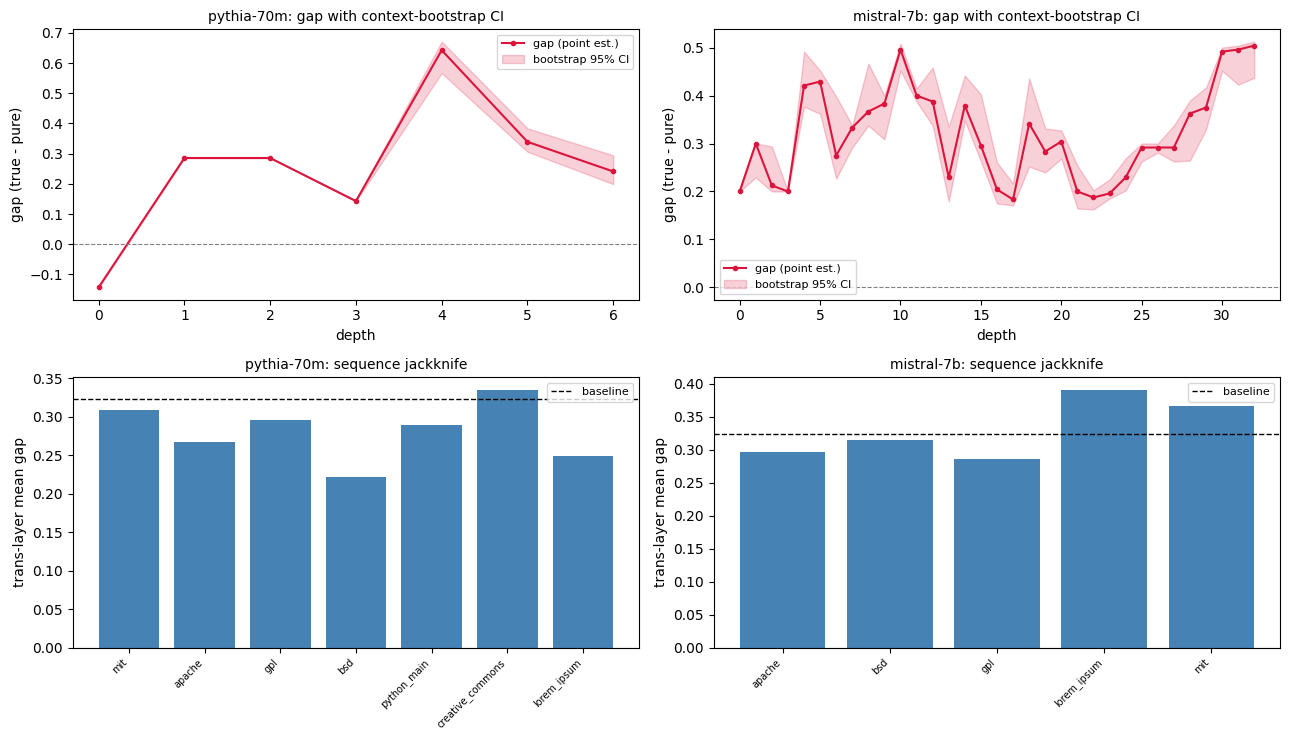

saved fig_mcb_jackknife_bootstrap.{png,pdf} + mcb_jackknife_bootstrap_results.json


In [10]:
# Figures (600 dpi + PDF)
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.dpi'] = 600
names = list(RESULTS)
fig, axes = plt.subplots(2, len(names), figsize=(6.5 * len(names), 7.5), squeeze=False)
for j, name in enumerate(names):
    r = RESULTS[name]
    D = len(r['gap'])
    ax = axes[0][j]
    ax.plot(range(D), r['gap'], color='crimson', marker='o', ms=3, label='gap (point est.)')
    lo = [c[0] for c in r['bootstrap']['per_depth_gap_ci95']]
    hi = [c[1] for c in r['bootstrap']['per_depth_gap_ci95']]
    ax.fill_between(range(D), lo, hi, color='crimson', alpha=0.2, label='bootstrap 95% CI')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_title(f'{name}: gap with context-bootstrap CI', fontsize=10)
    ax.set_xlabel('depth'); ax.set_ylabel('gap (true - pure)'); ax.legend(fontsize=8)
    ax = axes[1][j]
    keys = list(r['jackknife'])
    vals = [r['jackknife'][k]['trans_gap_mean'] for k in keys]
    ax.bar(range(len(keys)), vals, color='steelblue')
    ax.axhline(r['trans_gap_mean'], color='black', ls='--', lw=1, label='baseline')
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([k.replace('_license','').replace('_header','') for k in keys],
                       rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{name}: sequence jackknife', fontsize=10)
    ax.set_ylabel('trans-layer mean gap'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'fig_mcb_jackknife_bootstrap.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(OUT, 'fig_mcb_jackknife_bootstrap.pdf'), bbox_inches='tight')
plt.show()
print('saved fig_mcb_jackknife_bootstrap.{png,pdf} + mcb_jackknife_bootstrap_results.json')


## Reporting notes

These numbers replace the released simplified jackknife/bootstrap for Pythia-70M and
Mistral-7B. In the revision, describe them as the M/C/B-protocol statistics (commensurable
with the headline gaps) and remove or relabel the earlier mem-vs-prose variant. Only claim
"all jackknife gaps strictly positive" if that is what this run shows; report the smallest
jackknife value and which sequence drives it, as done for GPT-2 Medium.
